<a href="https://colab.research.google.com/github/cmanell/Colorectal_cancer_DL_project/blob/CNN_guillaume/Deep_Learning_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
print(torch.cuda.is_available())

True


# Deep Learning Project – PathMNIST

In this notebook we work on the classification of colorectal cancer tissue images using the PathMNIST dataset.

The goal is to train and compare different deep learning models:
- a simple dense network (MLP)
- a convolutional neural network (CNN)
- a pretrained ResNet model
- a Vision Transformer

We will also visualize the model predictions using Grad-CAM.

## 3. CNN from scratch

In this part, we build a convolutional neural network for PathMNIST classification.

The goal is to compare the same CNN:
- without data augmentation
- with data augmentation

We then compare the results and answer the questions from Part 3.

In [13]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

## 3.1. Transforms for the CNN

We prepare two versions of the training data:
- one without augmentation
- one with augmentation

The validation and test sets are kept unchanged.

In [14]:
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor()
])

In [15]:
data_flag = "pathmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

In [16]:
train_dataset_no_aug = DataClass(split="train", transform=basic_transform, download=True)
train_dataset_aug = DataClass(split="train", transform=aug_transform, download=True)

val_dataset = DataClass(split="val", transform=basic_transform, download=True)
test_dataset = DataClass(split="test", transform=basic_transform, download=True)

In [17]:
BATCH_SIZE = 128

train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## CNN architecture

The network contains 3 convolution blocks.
Each block has:
- convolution
- batch normalization
- ReLU
- max pooling
- dropout

In [18]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.20),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.30),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.40)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Linear(128, 9)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Training and evaluation functions

We define helper functions to train the model, evaluate it, and store the results.

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [20]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=40):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.6f} | "
            f"Val Loss: {val_loss:.6f} | Val Acc: {val_acc:.6f}"
        )

    model.load_state_dict(best_model_wts)
    return model, history

In [22]:
def plot_history(history, title_prefix="CNN"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [23]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [24]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("CNN Confusion Matrix")
    plt.show()

    return cm

## Experiment 1: CNN without augmentation

We first train the CNN without any data augmentation for 40 epochs.
This will help us observe possible overfitting.

In [25]:
cnn_no_aug = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_no_aug = optim.Adam(cnn_no_aug.parameters(), lr=0.001)

In [26]:
cnn_no_aug, history_no_aug = train_model(
    model=cnn_no_aug,
    train_loader=train_loader_no_aug,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_no_aug,
    device=device,
    num_epochs=40
)

Epoch 1/40 | Train Loss: 0.858165 | Train Acc: 0.683319 | Val Loss: 1.014508 | Val Acc: 0.628649
Epoch 2/40 | Train Loss: 0.565787 | Train Acc: 0.799602 | Val Loss: 0.719943 | Val Acc: 0.749100
Epoch 3/40 | Train Loss: 0.468801 | Train Acc: 0.836782 | Val Loss: 4.181597 | Val Acc: 0.224110
Epoch 4/40 | Train Loss: 0.426680 | Train Acc: 0.852605 | Val Loss: 1.612257 | Val Acc: 0.529088
Epoch 5/40 | Train Loss: 0.361853 | Train Acc: 0.876006 | Val Loss: 0.556640 | Val Acc: 0.803279
Epoch 6/40 | Train Loss: 0.327222 | Train Acc: 0.887806 | Val Loss: 1.107562 | Val Acc: 0.651739
Epoch 7/40 | Train Loss: 0.298112 | Train Acc: 0.900218 | Val Loss: 0.477710 | Val Acc: 0.823970
Epoch 8/40 | Train Loss: 0.274911 | Train Acc: 0.906585 | Val Loss: 1.006576 | Val Acc: 0.736905
Epoch 9/40 | Train Loss: 0.259697 | Train Acc: 0.913207 | Val Loss: 2.615443 | Val Acc: 0.589364
Epoch 10/40 | Train Loss: 0.243892 | Train Acc: 0.918074 | Val Loss: 1.406202 | Val Acc: 0.694022
Epoch 11/40 | Train Loss: 0.2

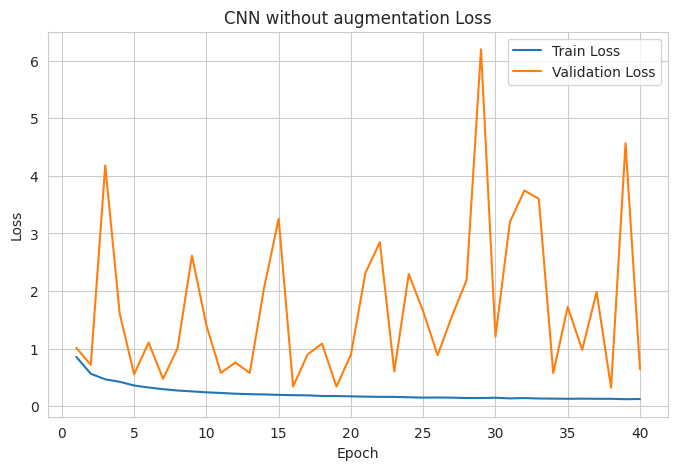

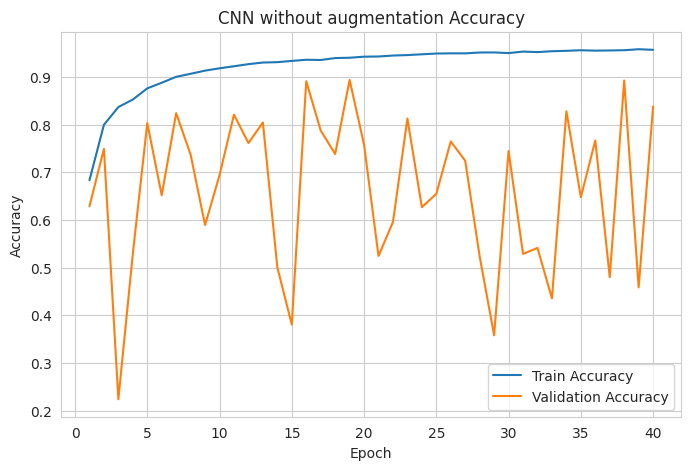

In [27]:
plot_history(history_no_aug, title_prefix="CNN without augmentation")

In [28]:
test_loss_no_aug, test_acc_no_aug = evaluate(cnn_no_aug, test_loader, criterion, device)
print("Test loss without augmentation:", test_loss_no_aug)
print("Test accuracy without augmentation:", test_acc_no_aug)

Test loss without augmentation: 0.8032832091233192
Test accuracy without augmentation: 0.8146239554317549


## Experiment 2: CNN with augmentation

We now train the same CNN with data augmentation.
Only the training transform changes.

In [29]:
cnn_aug = CNN().to(device)
optimizer_aug = optim.Adam(cnn_aug.parameters(), lr=0.001)

In [30]:
cnn_aug, history_aug = train_model(
    model=cnn_aug,
    train_loader=train_loader_aug,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_aug,
    device=device,
    num_epochs=40
)

Epoch 1/40 | Train Loss: 0.952026 | Train Acc: 0.646418 | Val Loss: 1.281679 | Val Acc: 0.550380
Epoch 2/40 | Train Loss: 0.680705 | Train Acc: 0.750100 | Val Loss: 1.624869 | Val Acc: 0.540384
Epoch 3/40 | Train Loss: 0.592756 | Train Acc: 0.785690 | Val Loss: 2.539890 | Val Acc: 0.471212
Epoch 4/40 | Train Loss: 0.525379 | Train Acc: 0.810858 | Val Loss: 0.675390 | Val Acc: 0.763794
Epoch 5/40 | Train Loss: 0.477495 | Train Acc: 0.830170 | Val Loss: 0.729542 | Val Acc: 0.729408
Epoch 6/40 | Train Loss: 0.435786 | Train Acc: 0.846560 | Val Loss: 4.072483 | Val Acc: 0.319872
Epoch 7/40 | Train Loss: 0.410590 | Train Acc: 0.856338 | Val Loss: 1.251762 | Val Acc: 0.644042
Epoch 8/40 | Train Loss: 0.383621 | Train Acc: 0.866494 | Val Loss: 0.863078 | Val Acc: 0.754098
Epoch 9/40 | Train Loss: 0.372027 | Train Acc: 0.871317 | Val Loss: 3.744333 | Val Acc: 0.404338
Epoch 10/40 | Train Loss: 0.349271 | Train Acc: 0.879495 | Val Loss: 0.521050 | Val Acc: 0.822771
Epoch 11/40 | Train Loss: 0.3

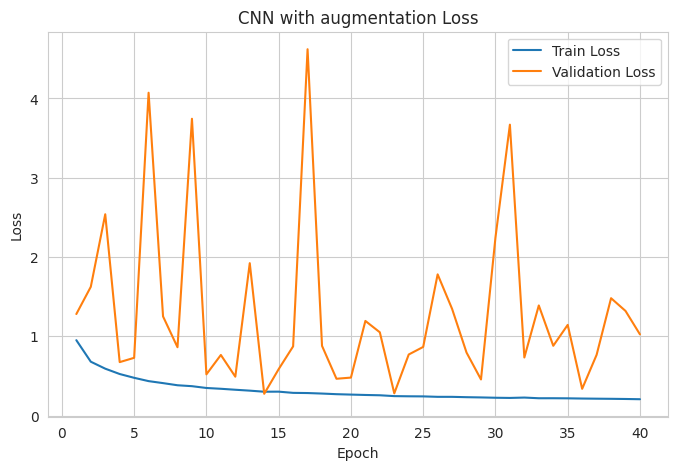

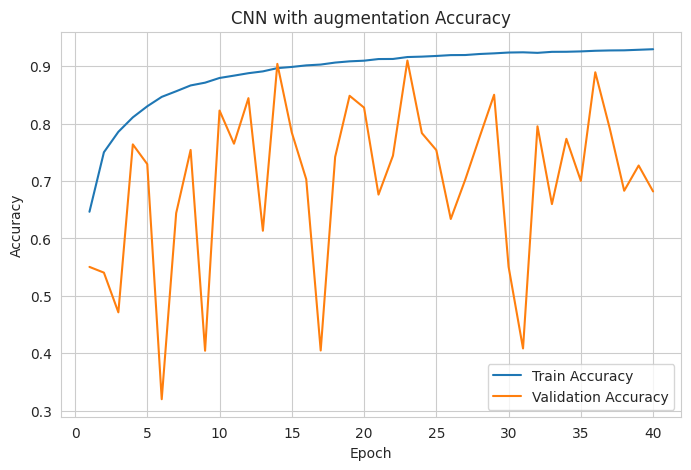

In [31]:
plot_history(history_aug, title_prefix="CNN with augmentation")

In [32]:
test_loss_aug, test_acc_aug = evaluate(cnn_aug, test_loader, criterion, device)
print("Test loss with augmentation:", test_loss_aug)
print("Test accuracy with augmentation:", test_acc_aug)

Test loss with augmentation: 1.1242384392404954
Test accuracy with augmentation: 0.7055710306406685


## Comparison of the two CNN runs

We compare the performance of the same architecture with and without augmentation.

In [33]:
results_cnn = {
    "Without augmentation": test_acc_no_aug,
    "With augmentation": test_acc_aug
}

for k, v in results_cnn.items():
    print(f"{k}: {v:.6f}")

Without augmentation: 0.814624
With augmentation: 0.705571


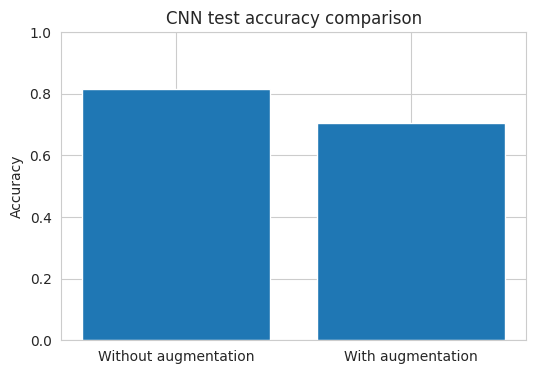

In [34]:
plt.figure(figsize=(6, 4))
plt.bar(results_cnn.keys(), results_cnn.values())
plt.title("CNN test accuracy comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Confusion matrix for the best CNN

We use the best CNN model on the test set and display its confusion matrix.

In [35]:
best_cnn = cnn_aug if test_acc_aug >= test_acc_no_aug else cnn_no_aug
best_name = "CNN with augmentation" if test_acc_aug >= test_acc_no_aug else "CNN without augmentation"

print("Best model:", best_name)

Best model: CNN without augmentation


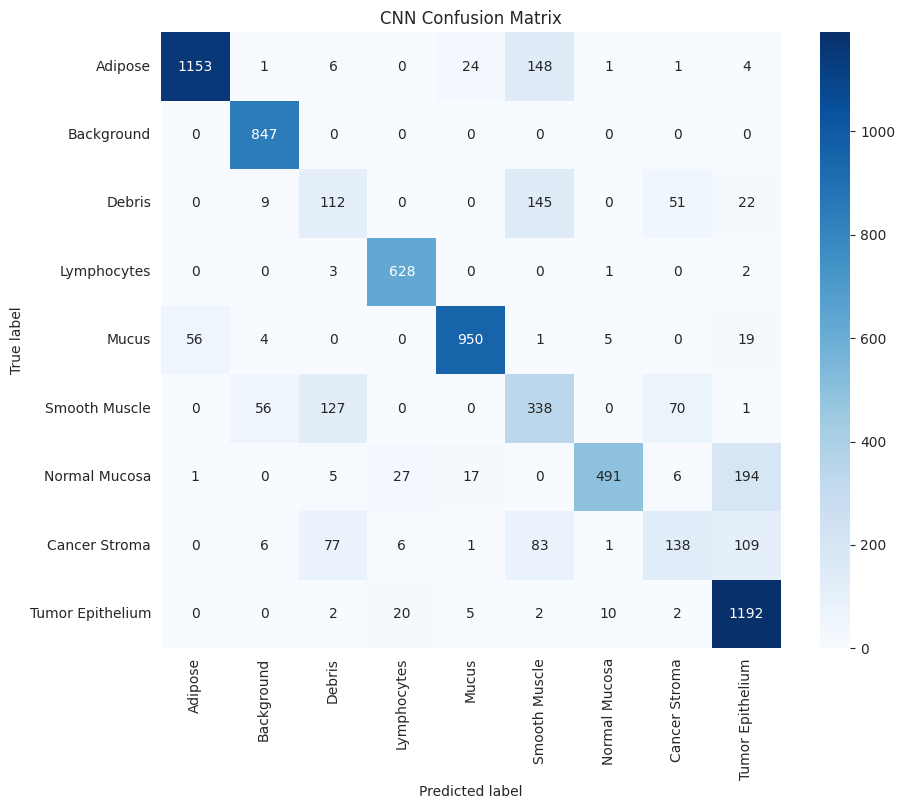

In [36]:
label_names = [
    "Adipose",
    "Background",
    "Debris",
    "Lymphocytes",
    "Mucus",
    "Smooth Muscle",
    "Normal Mucosa",
    "Cancer Stroma",
    "Tumor Epithelium"
]

y_true_cnn, y_pred_cnn = get_predictions(best_cnn, test_loader, device)
cm_cnn = plot_confusion_matrix(y_true_cnn, y_pred_cnn, label_names)

## Q3.1 - Overfitting without augmentation

We now look for the first epoch where the gap between training accuracy and validation accuracy is greater than 15 percentage points.

In [37]:
first_epoch_gap = None

for i, (train_acc, val_acc) in enumerate(zip(history_no_aug["train_acc"], history_no_aug["val_acc"])):
    gap = train_acc - val_acc
    if gap > 0.15:
        first_epoch_gap = i + 1
        print("First epoch where the gap exceeds 15 percentage points:", first_epoch_gap)
        print("Train accuracy:", train_acc)
        print("Validation accuracy:", val_acc)
        print("Gap:", gap)
        break

if first_epoch_gap is None:
    print("The gap never exceeded 15 percentage points in the 40 epochs.")

First epoch where the gap exceeds 15 percentage points: 3
Train accuracy: 0.8367816347393218
Validation accuracy: 0.22411035585765693
Gap: 0.6126712788816648


### Answer to Q3.1

The first epoch where the gap between training accuracy and validation accuracy exceeds 15 percentage points is the epoch reported above.

This suggests that the model starts to overfit the training data at this point.
The training accuracy keeps improving, while the validation accuracy does not improve at the same rate.

## Q3.2 - Data augmentation choices

A useful augmentation for histology images is rotation or flipping.
This makes sense because tissue patches do not have a fixed natural orientation.

A harmful or meaningless augmentation would be something like a strong color transformation that changes the staining too much.
In histology, color carries important information, so unrealistic color changes could damage the biological meaning of the image.

## Q3.3 - Number of parameters

We compute the total number of trainable parameters in the CNN.
We also manually compute the number of parameters in the first convolution layer.

In [38]:
num_params_cnn = sum(p.numel() for p in best_cnn.parameters() if p.requires_grad)
print("Total number of trainable parameters:", num_params_cnn)

Total number of trainable parameters: 242441


For the first convolution layer:

- input channels = 3
- output channels = 32
- kernel size = 3 x 3

The formula is:

(number of input channels × kernel height × kernel width + 1 bias) × number of output channels

So we get:

(3 × 3 × 3 + 1) × 32 = (27 + 1) × 32 = 896

So the first convolution layer has 896 trainable parameters.

The CNN trained without augmentation achieved a higher test accuracy (around 0.81) compared to the model trained with augmentation (around 0.70).
One possible explanation is that PathMNIST images are very small (28×28), and some augmentation operations such as rotations may distort the visual patterns.
Additionally, the CNN already includes regularization techniques such as batch normalization and dropout, which may reduce the need for additional augmentation.

## 6. Grad-CAM visualization

Deep neural networks are often considered as "black box" models.  
Grad-CAM helps us understand which regions of an image influence the prediction of the CNN.

Grad-CAM generates a heatmap that highlights the most important areas used by the model when making a prediction.

In this section, we apply Grad-CAM to visualize the regions that the CNN focuses on for some test images.

In [39]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=ec20c9a7c88f4fba3ee764cac0bf22903e9b09428084825ac67234b6e8fd67cb
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


### Grad-CAM setup

We import the required tools to compute Grad-CAM explanations.

In [40]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

### Target layer selection

Grad-CAM works on convolutional feature maps.  
We therefore select the last convolution layer of the CNN as the target layer.

This layer contains high-level visual features learned by the model.

In [41]:
target_layer = best_cnn.features[-5]

### Selecting a test image

We select an example image from the test dataset.  
This image will be used to visualize where the CNN focuses when making a prediction.

In [42]:
img, label = test_dataset[0]

input_tensor = img.unsqueeze(0).to(device)

### Model prediction

Before applying Grad-CAM, we check which class the CNN predicts for this image.

In [43]:
best_cnn.eval()

with torch.no_grad():
    outputs = best_cnn(input_tensor)
    pred_class = outputs.argmax(dim=1).item()

print("True label:", label)
print("Predicted label:", pred_class)

True label: [8]
Predicted label: 8


### Grad-CAM computation

Grad-CAM computes gradients of the predicted class with respect to the feature maps of the selected convolution layer.

These gradients are used to produce a heatmap showing which parts of the image contribute most to the prediction.

In [44]:
cam = GradCAM(model=best_cnn, target_layers=[target_layer])

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

grayscale_cam = grayscale_cam[0]

### Visualization

The Grad-CAM heatmap is overlaid on the original image to highlight the regions that influence the CNN prediction.

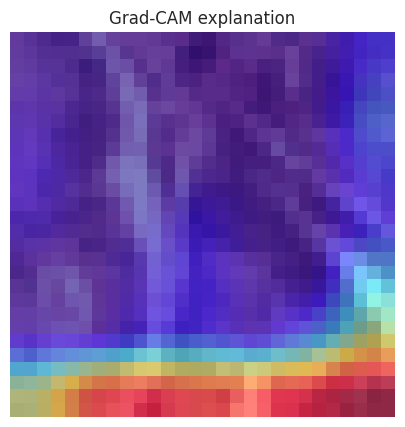

In [45]:
rgb_img = img.permute(1, 2, 0).numpy()

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")
plt.title("Grad-CAM explanation")
plt.show()

### Original image and Grad-CAM visualization

Below we display the original image from the test set and the Grad-CAM heatmap showing which regions influenced the CNN prediction.

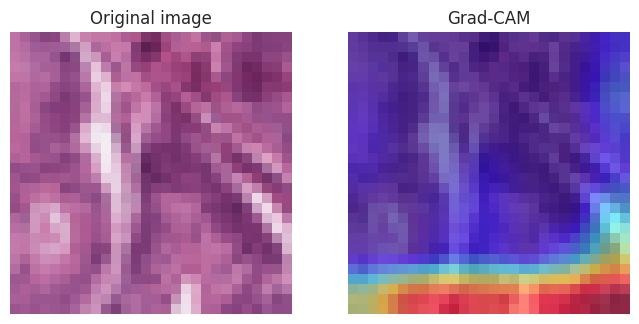

In [46]:
# convertir l'image pour matplotlib
rgb_img = img.permute(1, 2, 0).numpy()

# calcul de la heatmap
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# affichage côte à côte
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

### Interpretation

The Grad-CAM heatmap highlights the regions of the image that were most important for the CNN prediction.

In many cases, the highlighted areas correspond to meaningful tissue structures in the histology image.

This suggests that the model is learning relevant visual patterns rather than relying on random image regions.

### Grad-CAM visualization on multiple test images

To better understand how the CNN makes its predictions, we visualize Grad-CAM explanations for several images from the test set.

For each example, we show:
- the original image
- the Grad-CAM heatmap
- the true label and predicted label

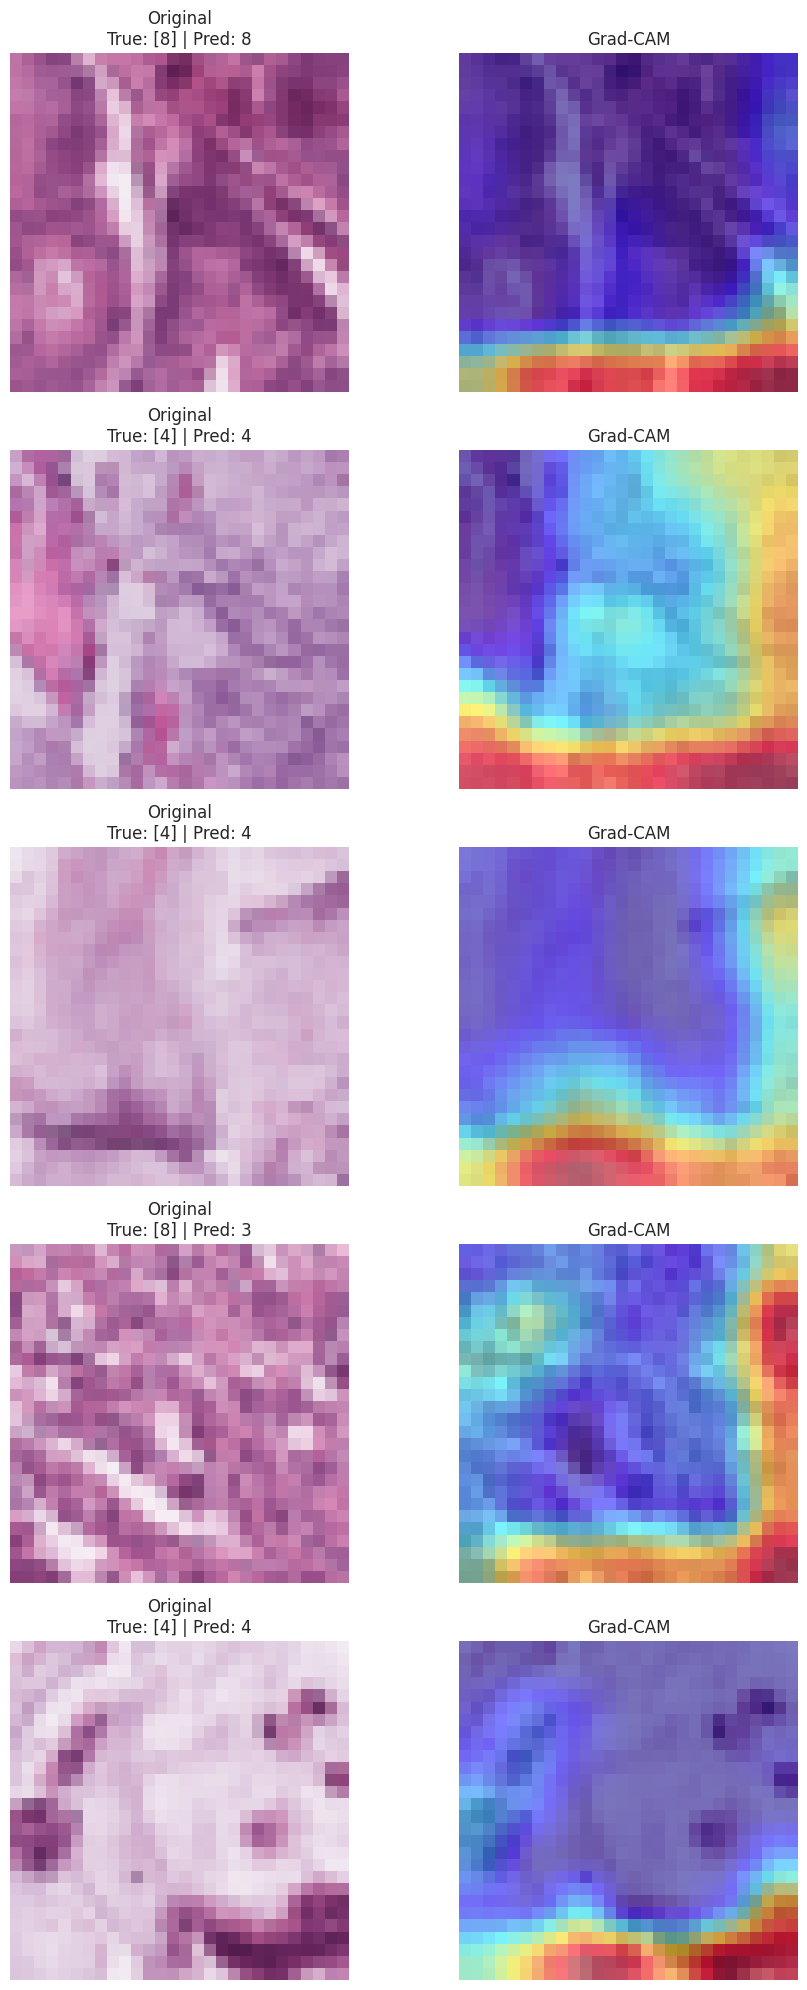

In [47]:
num_images = 5

plt.figure(figsize=(10, 4*num_images))

for i in range(num_images):

    img, label = test_dataset[i]
    input_tensor = img.unsqueeze(0).to(device)

    # prediction
    best_cnn.eval()
    with torch.no_grad():
        outputs = best_cnn(input_tensor)
        pred_class = outputs.argmax(dim=1).item()

    # GradCAM
    cam = GradCAM(model=best_cnn, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # conversion image
    rgb_img = img.permute(1,2,0).numpy()
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # image originale
    plt.subplot(num_images,2,2*i+1)
    plt.imshow(rgb_img)
    plt.title(f"Original\nTrue: {label} | Pred: {pred_class}")
    plt.axis("off")

    # GradCAM
    plt.subplot(num_images,2,2*i+2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis("off")

plt.tight_layout()
plt.show()

The Grad-CAM visualizations highlight the regions that contribute most to the CNN prediction.

In many examples, the model focuses on meaningful tissue structures rather than random areas of the image. This suggests that the CNN has learned relevant visual patterns for distinguishing between tissue types.